In [3]:
# PHYS 311
# BLOCK 1 CHECKPOINT - BUNGEE JUMPER
# Alexander Berry
# September 8, 2026

# IMPORT TOOLS

import numpy as np
import matplotlib.pyplot as plt

## Block 1 Checkpoint - Bungee Jumper

For this checkpoint, I modeled a one-dimensional bungee jumper using the Euler-Cromer method. The jumper begins at rest and falls downward due to gravity. The bungee cord has a natural length of 20 m, meaning that it exerts no force while the jumper is within that distance. Beyond that however, the cord stretches and produceds an upward spring force proportiopnal to the amount of extension. 

Because no air resistance or damping is included, the model predicts that the jumper will continue oscillating while the total mechanical energy remains approximately constant. 

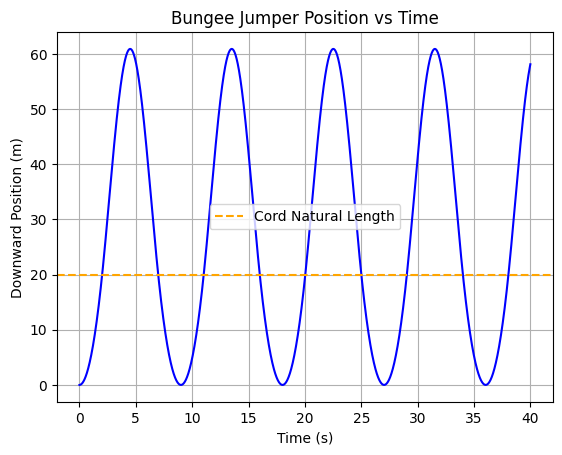

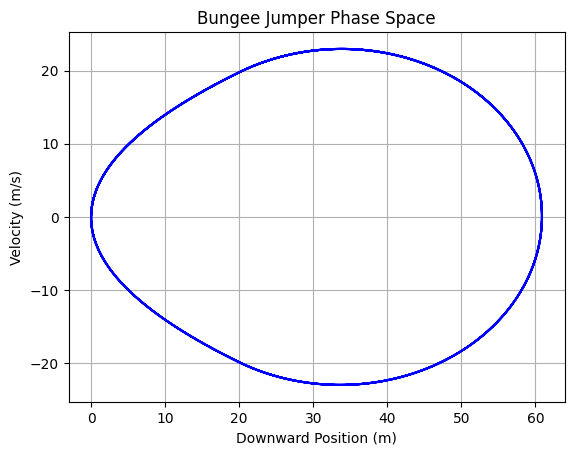

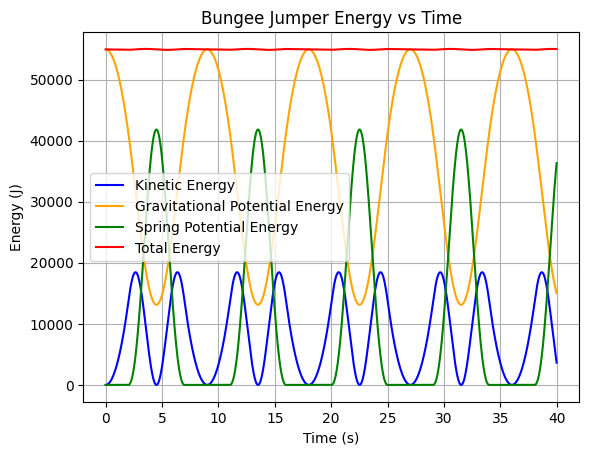

VALIDATION 1 - ENERGY CONSERVATION

Initial total energy: 54936.000 J
Maximum energy drift: 78.052 J
Maximum energy drift percentage: 0.1421 %


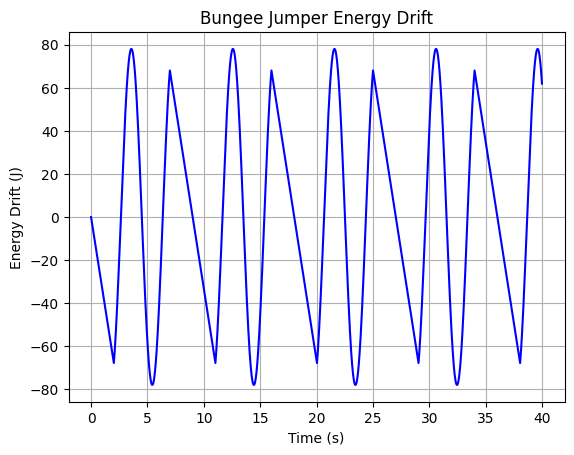


VALIDATION 2 - CONVERGENCE TEST

dt = 0.10000 s, Maximum energy drift = 846.373 J
dt = 0.05000 s, Maximum energy drift = 399.758 J
dt = 0.02500 s, Maximum energy drift = 196.199 J
dt = 0.01250 s, Maximum energy drift = 98.017 J
dt = 0.00625 s, Maximum energy drift = 48.765 J

Measured convergence order: 1.026


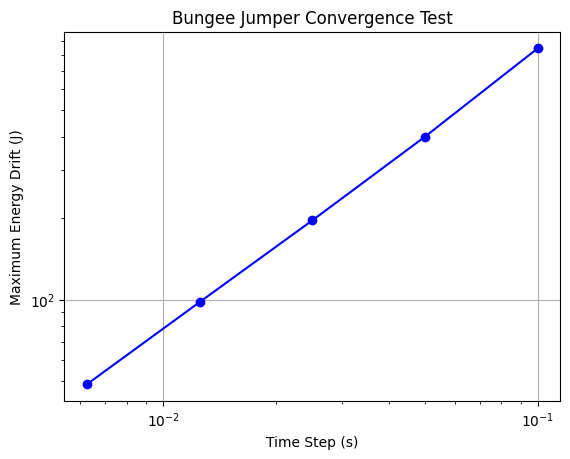


ADDITIONAL CHECK - EXACT FREE FALL

Exact cord engagement time: 2.0193 s
Numerical cord engagement time: 2.0200 s
Time difference: 0.0007 s

Exact velocity at cord engagement: 19.8091 m/s
Numerical velocity at cord engagement: 19.8162 m/s
Velocity difference: 0.0071 m/s

FINAL RESULTS

Maximum downward position: 60.900 m
Maximum cord stretch: 40.900 m
Minimum ground clearance: 19.100 m


In [4]:
# BUNGEE JUMPER SIMULATION

# 1. VALUES

m = 70.0
g = 9.81
k = 50.0
L0 = 20.0
H = 80.0

x0 = 0.0
v0 = 0.0

dt = 0.01
t_final = 40.0


# 2. BUNGEE JUMPER FUNCTION

def simulate_bungee(dt, t_final=40.0):

    # Starting position, velocity, and time
    x = x0
    v = v0
    t = 0.0

    # Starting spring stretch
    stretch = max(0.0, x - L0)

    # Starting energies
    KE = 0.5 * m * v**2
    PE_gravity = m * g * (H - x)
    PE_spring = 0.5 * k * stretch**2
    E_total = KE + PE_gravity + PE_spring

    # Lists to store values
    t_list = [t]
    x_list = [x]
    v_list = [v]
    KE_list = [KE]
    PE_gravity_list = [PE_gravity]
    PE_spring_list = [PE_spring]
    E_list = [E_total]

    # Calculate until the final simulation time is reached
    while t < t_final:

        # Calculate spring stretch
        stretch = max(0.0, x - L0)

        # Forces
        F_gravity = m * g
        F_spring = -k * stretch

        # Acceleration
        a = (F_gravity + F_spring) / m

        # Euler-Cromer method
        v_new = v + a * dt
        x_new = x + v_new * dt

        x = x_new
        v = v_new

        # Update time
        t += dt

        # Recalculate spring stretch and energies
        stretch = max(0.0, x - L0)

        KE = 0.5 * m * v**2
        PE_gravity = m * g * (H - x)
        PE_spring = 0.5 * k * stretch**2
        E_total = KE + PE_gravity + PE_spring

        # Append new values to lists
        t_list.append(t)
        x_list.append(x)
        v_list.append(v)
        KE_list.append(KE)
        PE_gravity_list.append(PE_gravity)
        PE_spring_list.append(PE_spring)
        E_list.append(E_total)

    # Convert lists to numpy arrays for easier handling
    return (
        np.array(t_list),
        np.array(x_list),
        np.array(v_list),
        np.array(KE_list),
        np.array(PE_gravity_list),
        np.array(PE_spring_list),
        np.array(E_list)
    )


# 3. RUN SIMULATION

t, x, v, KE, PE_gravity, PE_spring, E_total = simulate_bungee(dt, t_final)


# 4. PLOT POSITION VS TIME

plt.figure()

plt.plot(t, x, color='blue')
plt.axhline(L0, color='orange', linestyle='--', label='Cord Natural Length')

plt.xlabel('Time (s)')
plt.ylabel('Downward Position (m)')
plt.title('Bungee Jumper Position vs Time')

plt.legend()
plt.grid()
plt.show()


# 5. PLOT PHASE SPACE

plt.figure()

plt.plot(x, v, color='blue')

plt.xlabel('Downward Position (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Bungee Jumper Phase Space')

plt.grid()
plt.show()


# 6. PLOT ENERGY VS TIME

plt.figure()

plt.plot(t, KE, label='Kinetic Energy', color='blue')
plt.plot(t, PE_gravity, label='Gravitational Potential Energy', color='orange')
plt.plot(t, PE_spring, label='Spring Potential Energy', color='green')
plt.plot(t, E_total, label='Total Energy', color='red')

plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Bungee Jumper Energy vs Time')

plt.legend()
plt.grid()
plt.show()


# VALIDATION 1 - ENERGY CONSERVATION

# 7. CALCULATE ENERGY DRIFT

energy_drift = E_total - E_total[0]
max_energy_drift = np.max(np.abs(energy_drift))
energy_drift_percent = (max_energy_drift / E_total[0]) * 100

print("VALIDATION 1 - ENERGY CONSERVATION")
print()

print(f"Initial total energy: {E_total[0]:.3f} J")
print(f"Maximum energy drift: {max_energy_drift:.3f} J")
print(f"Maximum energy drift percentage: {energy_drift_percent:.4f} %")


# 8. PLOT ENERGY DRIFT

plt.figure()

plt.plot(t, energy_drift, color='blue')

plt.xlabel('Time (s)')
plt.ylabel('Energy Drift (J)')
plt.title('Bungee Jumper Energy Drift')

plt.grid()
plt.show()


# VALIDATION 2 - CONVERGENCE TEST

# 9. TIME STEP VALUES

dt_values = np.array([0.1, 0.05, 0.025, 0.0125, 0.00625])

max_drift_values = []


# 10. RUN CONVERGENCE TEST

for dt_test in dt_values:

    t_test, x_test, v_test, KE_test, PE_gravity_test, PE_spring_test, E_test = simulate_bungee(
        dt_test,
        t_final
    )

    # Calculate energy drift
    energy_drift_test = E_test - E_test[0]
    max_drift = np.max(np.abs(energy_drift_test))

    max_drift_values.append(max_drift)

# Convert list to numpy array
max_drift_values = np.array(max_drift_values)


# 11. CALCULATE CONVERGENCE ORDER

coefficients = np.polyfit(
    np.log(dt_values),
    np.log(max_drift_values),
    1
)

convergence_order = coefficients[0]

print()
print("VALIDATION 2 - CONVERGENCE TEST")
print()

for i in range(len(dt_values)):
    print(
        f"dt = {dt_values[i]:.5f} s, "
        f"Maximum energy drift = {max_drift_values[i]:.3f} J"
    )

print()
print(f"Measured convergence order: {convergence_order:.3f}")


# 12. PLOT CONVERGENCE TEST

plt.figure()

plt.loglog(dt_values, max_drift_values, marker='o', color='blue')

plt.xlabel('Time Step (s)')
plt.ylabel('Maximum Energy Drift (J)')
plt.title('Bungee Jumper Convergence Test')

plt.grid()
plt.show()


# ADDITIONAL CHECK - EXACT FREE FALL

# 13. EXACT FREE-FALL VALUES

t_taut_exact = np.sqrt(2 * L0 / g)
v_taut_exact = np.sqrt(2 * g * L0)

# Find first point where the cord becomes taut
taut_index = np.where(x >= L0)[0][0]

t_taut = t[taut_index]
v_taut = v[taut_index]

# Calculate differences
time_difference = abs(t_taut - t_taut_exact)
velocity_difference = abs(v_taut - v_taut_exact)

print()
print("ADDITIONAL CHECK - EXACT FREE FALL")
print()

print(f"Exact cord engagement time: {t_taut_exact:.4f} s")
print(f"Numerical cord engagement time: {t_taut:.4f} s")
print(f"Time difference: {time_difference:.4f} s")

print()

print(f"Exact velocity at cord engagement: {v_taut_exact:.4f} m/s")
print(f"Numerical velocity at cord engagement: {v_taut:.4f} m/s")
print(f"Velocity difference: {velocity_difference:.4f} m/s")


# FINAL RESULTS

# 14. MAXIMUM POSITION AND GROUND CLEARANCE

maximum_position = np.max(x)
maximum_stretch = maximum_position - L0
minimum_ground_clearance = H - maximum_position

print()
print("FINAL RESULTS")
print()

print(f"Maximum downward position: {maximum_position:.3f} m")
print(f"Maximum cord stretch: {maximum_stretch:.3f} m")
print(f"Minimum ground clearance: {minimum_ground_clearance:.3f} m")

## Results

The numerical results agree with the previously described physical expectations. The jumper reached a maximum downward position of approximately 60.900 m (40.900 m of cable stretching). The position and phase-space plots help demonstrate how repeated oscillatory motion as energy transfers betewen kinetic, gravitational potential, and spring potential energy throughout the process.

Furthermore, I used energy conservation and convergence testing to validate the simulation. With a time step (dt) of 0.01 s, the maximum total energy drit was approximately 78.052 J or 0.1421 % of the intial energy. When the time step was repeatedly halved, the maximum energy-error decreased by approximately a factor of two. The measured convergence order was found to be 1.026, which is generally consistent with the expected first-order behavior of Euler-Cromer. 

As an additional check, I compared the simulation to the exact free fakk solution before the cord became taut. The numerical time of engagement was 2.020 s, compared to the exact value of 2.0193 s,  demonstrates extremely close agreement! 

Overall, these results support the numerical model accurately represented an idealized bungee-jumper system!